# **Task 2: EEG Signal Analysis (Brain-Computer Interface)**

In [19]:
import sys
import os

if 'google.colab' in sys.modules:
    print('Running on Colab, installing MNE...')
    !pip install -qqq mne
    !pip install -qqq scikit-learn
    !pip install -qqq matplotlib
    !pip install -qqq seaborn
    !pip install -qqq scipy
    print('MNE and other packages installed.')
else:
    print('Not running on Colab, assuming MNE is installed.')

Running on Colab, installing MNE...
MNE and other packages installed.


In [20]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

mne.set_log_level('WARNING')

In [21]:
tmin, tmax = -1., 4.
event_id = dict(T1=2, T2=3)

subject = 1
runs = [3, 7, 11]
raw_fnames = mne.datasets.eegbci.load_data(subject, runs, path='./data')

raw = mne.io.read_raw_edf(raw_fnames[0], preload=True, verbose=False)
mne.datasets.eegbci.standardize(raw)

if len(raw_fnames) > 1:
    for f_name in raw_fnames[1:]:
        raw_tmp = mne.io.read_raw_edf(f_name, preload=True, verbose=False)
        mne.datasets.eegbci.standardize(raw_tmp)
        raw.append(raw_tmp)

eeg_picks = mne.pick_types(raw.info, eeg=True, meg=False, stim=False, eog=False, exclude='bads')

eog_channels = ['HEOG', 'VEOG']
raw.info['bads'].extend([ch for ch in eog_channels if ch in raw.ch_names])

montage = mne.channels.make_standard_montage('standard_1005')
raw.set_montage(montage, on_missing='ignore')

<RawEDF | S001R03.edf, 64 x 60000 (375.0 s), ~29.4 MiB, data loaded>

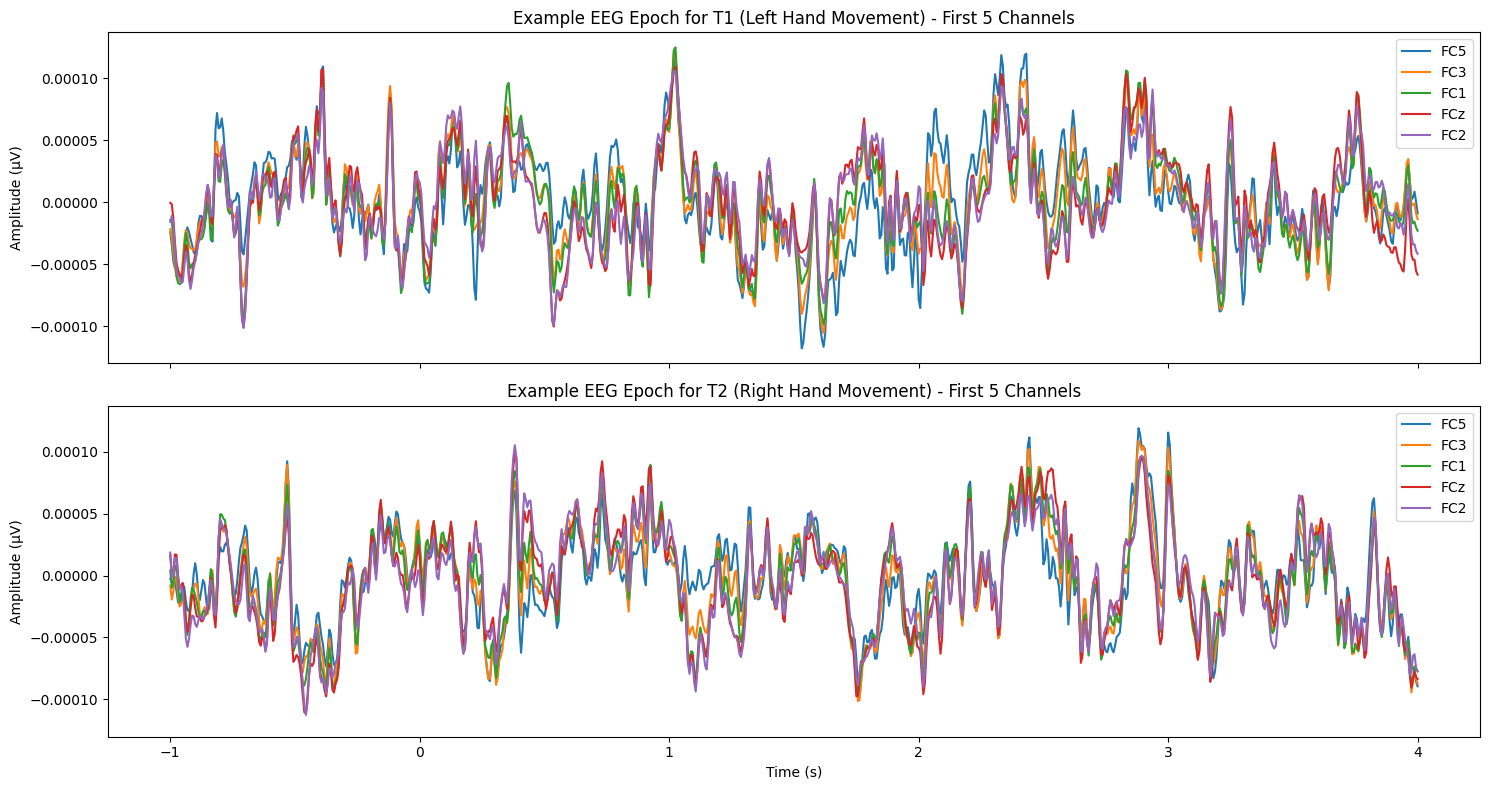

In [22]:

example_epoch_T1 = epochs_eeg['T1'][0]

example_epoch_T2 = epochs_eeg['T2'][0]

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True, sharey=True)

data_T1 = example_epoch_T1.get_data(picks=eeg_picks[:5]).squeeze()
times = example_epoch_T1.times

for i in range(data_T1.shape[0]):
    axes[0].plot(times, data_T1[i, :], label=example_epoch_T1.ch_names[eeg_picks[i]])

axes[0].set_title('Example EEG Epoch for T1 (Left Hand Movement) - First 5 Channels')
axes[0].set_ylabel('Amplitude (µV)')
axes[0].legend()

data_T2 = example_epoch_T2.get_data(picks=eeg_picks[:5]).squeeze()

for i in range(data_T2.shape[0]):
    axes[1].plot(times, data_T2[i, :], label=example_epoch_T2.ch_names[eeg_picks[i]])

axes[1].set_title('Example EEG Epoch for T2 (Right Hand Movement) - First 5 Channels')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude (µV)')
axes[1].legend()

plt.tight_layout()
plt.show()

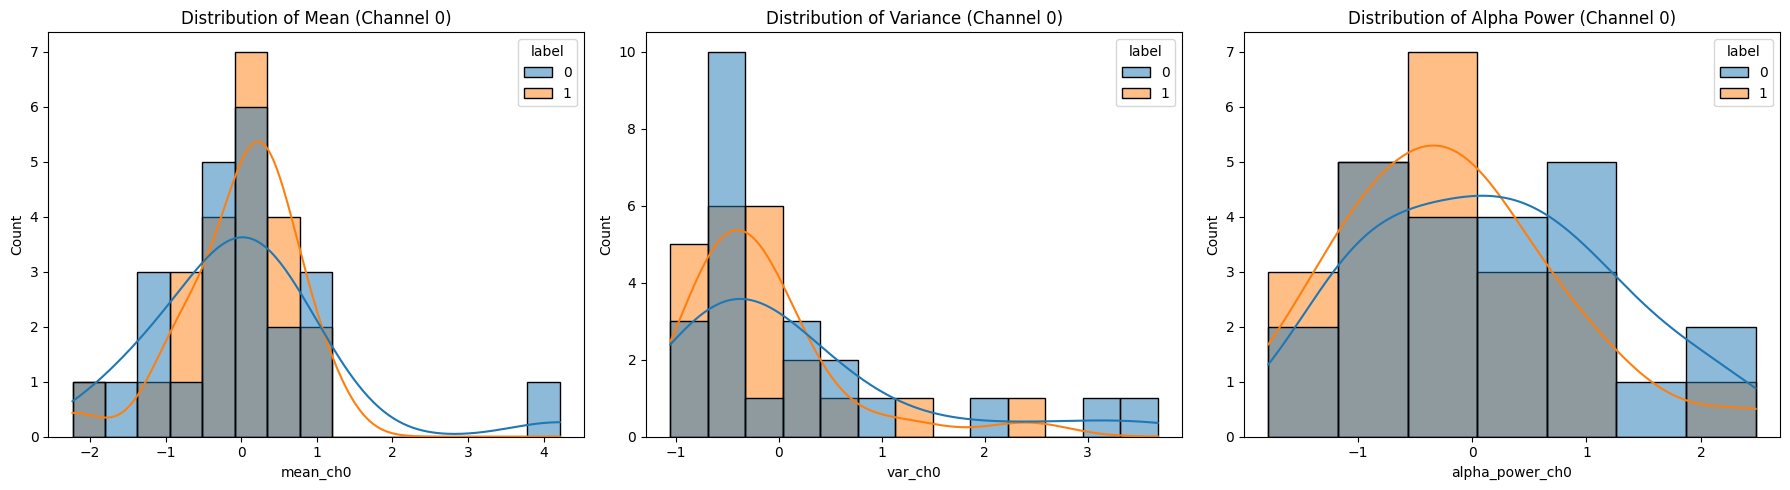

In [23]:

feature_names = [
    *[f'mean_ch{i}' for i in range(X.shape[1])],
    *[f'var_ch{i}' for i in range(X.shape[1])],
    *[f'rms_ch{i}' for i in range(X.shape[1])],
    *[f'{band}_power_ch{i}' for band in bands.keys() for i in range(X.shape[1])]
]

features_df = pd.DataFrame(features_scaled, columns=feature_names)
features_df['label'] = y_mapped

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=features_df, x='mean_ch0', hue='label', kde=True, ax=axes[0])
axes[0].set_title('Distribution of Mean (Channel 0)')

sns.histplot(data=features_df, x='var_ch0', hue='label', kde=True, ax=axes[1])
axes[1].set_title('Distribution of Variance (Channel 0)')

sns.histplot(data=features_df, x='alpha_power_ch0', hue='label', kde=True, ax=axes[2])
axes[2].set_title('Distribution of Alpha Power (Channel 0)')

plt.tight_layout()
plt.show()

--- Sample Predictions vs Actual (Random Forest) ---
   Actual  Predicted
0       1          0
1       0          1
2       0          1
3       1          1
4       0          1
5       0          0
6       1          1
7       1          0
8       0          0


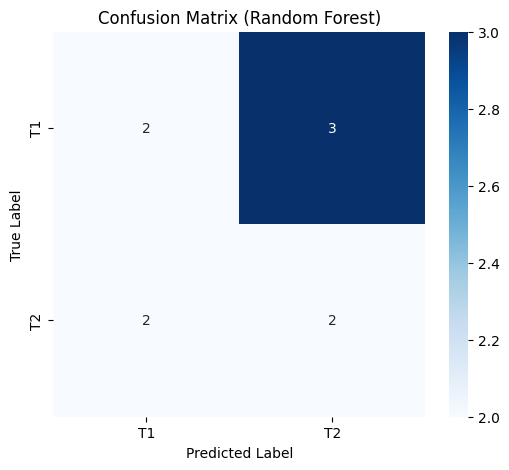

In [24]:

print("--- Sample Predictions vs Actual (Random Forest) ---")

sample_size = min(10, len(y_test))
sample_indices = np.random.choice(len(y_test), sample_size, replace=False)

sample_actual = y_test[sample_indices]
sample_predicted = y_pred_rf[sample_indices]

prediction_df = pd.DataFrame({
    'Actual': sample_actual,
    'Predicted': sample_predicted
})

print(prediction_df)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues',
            xticklabels=epochs_eeg.event_id.keys(), yticklabels=epochs_eeg.event_id.keys())
plt.title('Confusion Matrix (Random Forest)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [25]:
f_low, f_high = 0.5, 40.
raw.filter(f_low, f_high, fir_design='firwin', skip_by_annotation='edge')

events, _ = mne.events_from_annotations(raw, event_id=event_id)

epochs = mne.Epochs(raw, events, event_id, tmin, tmax, proj=True, picks=eeg_picks,
                    baseline=None, preload=True, verbose=False)

epochs_eeg = epochs[['T1', 'T2']]

In [26]:
X = epochs_eeg.get_data()
y = epochs_eeg.events[:, -1]

labels = np.array([event_id[k] for k in epochs_eeg.event_id.keys()])
y_mapped = np.array([np.where(labels == val)[0][0] for val in y])

def extract_features(epochs_data, sfreq, bands):
    features = []
    for epoch in epochs_data:
        epoch_features = []

        epoch_features.append(np.mean(epoch, axis=1))
        epoch_features.append(np.var(epoch, axis=1))
        epoch_features.append(np.sqrt(np.mean(epoch**2, axis=1)))

        psds, freqs = mne.time_frequency.psd_array_welch(epoch, sfreq=sfreq, fmin=0.5, fmax=40, verbose=False)

        for band_name, (fmin, fmax) in bands.items():
            idx_band = np.logical_and(freqs >= fmin, freqs <= fmax)
            band_power = np.mean(psds[:, idx_band], axis=1)
            epoch_features.append(band_power)

        features.append(np.concatenate(epoch_features))
    return np.array(features)

sfreq = raw.info['sfreq']
bands = {
    'theta': (4, 8),
    'alpha': (8, 12),
    'low_beta': (12, 20),
    'high_beta': (20, 30),
    'gamma': (30, 40)
}

features = extract_features(X, sfreq, bands)

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

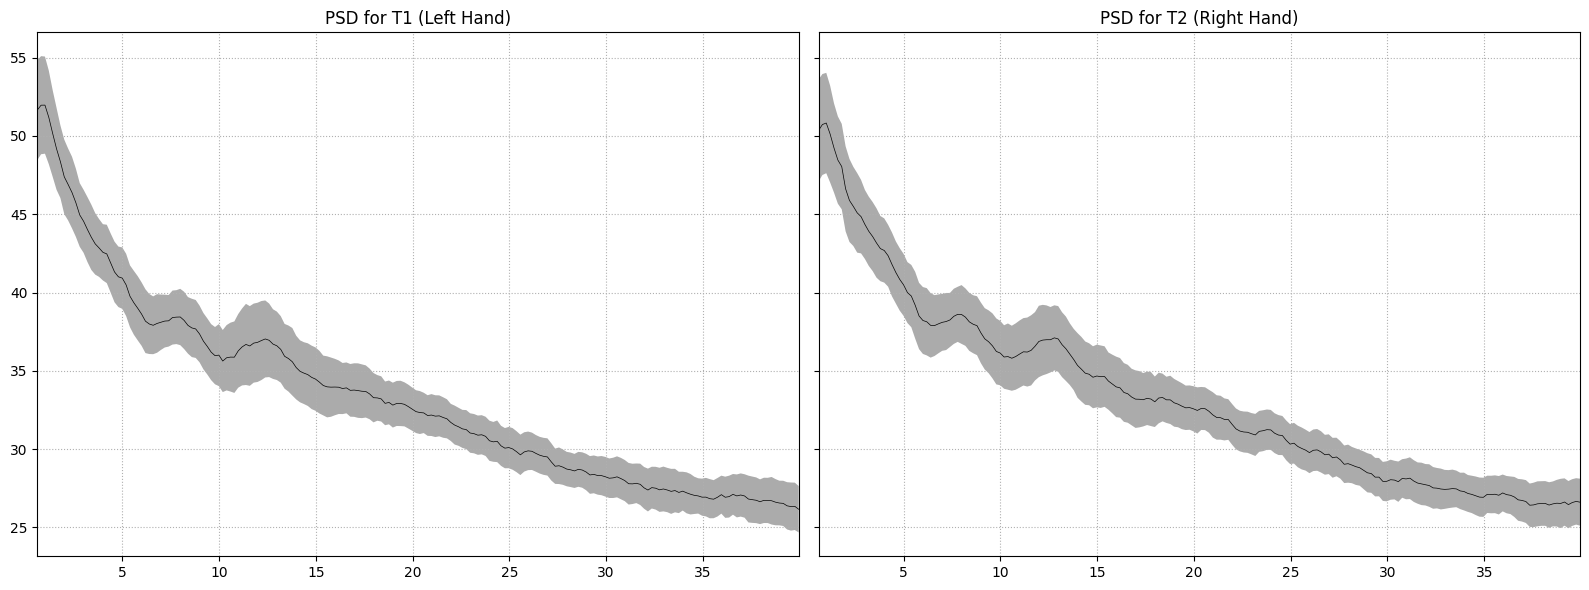

In [27]:

epochs_T1 = epochs_eeg['T1']
epochs_T2 = epochs_eeg['T2']

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

epochs_T1.plot_psd(fmin=0.5, fmax=40, average=True, spatial_colors=False, ax=axes[0], show=False)
axes[0].set_title('PSD for T1 (Left Hand)')

epochs_T2.plot_psd(fmin=0.5, fmax=40, average=True, spatial_colors=False, ax=axes[1], show=False)
axes[1].set_title('PSD for T2 (Right Hand)')

plt.tight_layout()
plt.show()

In [28]:
X_train, X_test, y_train, y_test = train_test_split(features_scaled, y_mapped, test_size=0.2, random_state=42, stratify=y_mapped)


print("\n--- Support Vector Machine (SVM) ---")
svm_pipeline = make_pipeline(StandardScaler(), SVC(random_state=42))

cv_scores_svm = cross_val_score(svm_pipeline, features_scaled, y_mapped, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='accuracy')
print(f"SVM Cross-validation accuracy: {cv_scores_svm.mean():.4f} +/- {cv_scores_svm.std():.4f}")

svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)

print(f"SVM Accuracy on test set: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"SVM Precision on test set: {precision_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(f"SVM Recall on test set: {recall_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(f"SVM F1-score on test set: {f1_score(y_test, y_pred_svm, average='weighted'):.4f}")
print("SVM Confusion Matrix on test set:\n", confusion_matrix(y_test, y_pred_svm))

print("\n--- Random Forest Classifier ---")
rf_pipeline = make_pipeline(StandardScaler(), RandomForestClassifier(random_state=42))

cv_scores_rf = cross_val_score(rf_pipeline, features_scaled, y_mapped, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='accuracy')
print(f"Random Forest Cross-validation accuracy: {cv_scores_rf.mean():.4f} +/- {cv_scores_rf.std():.4f}")

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print(f"Random Forest Accuracy on test set: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest Precision on test set: {precision_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"Random Forest Recall on test set: {recall_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"Random Forest F1-score on test set: {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print("Random Forest Confusion Matrix on test set:\n", confusion_matrix(y_test, y_pred_rf))


--- Support Vector Machine (SVM) ---
SVM Cross-validation accuracy: 0.5778 +/- 0.1296
SVM Accuracy on test set: 0.3333
SVM Precision on test set: 0.3333
SVM Recall on test set: 0.3333
SVM F1-score on test set: 0.3333
SVM Confusion Matrix on test set:
 [[2 3]
 [3 1]]

--- Random Forest Classifier ---
Random Forest Cross-validation accuracy: 0.5778 +/- 0.1296
Random Forest Accuracy on test set: 0.3333
Random Forest Precision on test set: 0.3333
Random Forest Recall on test set: 0.3333
Random Forest F1-score on test set: 0.3333
Random Forest Confusion Matrix on test set:
 [[2 3]
 [3 1]]
